<a href="https://colab.research.google.com/github/limerya/FINAL_bigdata/blob/main/bigdata_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType, DoubleType

spark = (
    SparkSession.builder
        .appName("gdelt_pipeline")
        .config("spark.sql.shuffle.partitions", "64")
        .config("spark.driver.memory", "8g")
        .config("spark.sql.execution.arrow.pyspark.enabled", "true")
        .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print(spark.version)

4.0.2


Data preprocessing

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os

RAW_DIR = '/content/drive/MyDrive/gdelt_data/raw'
CLEAN_DIR = '/content/drive/MyDrive/gdelt_data/cleaned'
PROCESSED_DIR = '/content/drive/MyDrive/gdelt_data/processed'

os.makedirs(CLEAN_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

# Spark reads the whole directory of parquet files in one shot — no glob needed
sdf = spark.read.parquet(f'{RAW_DIR}/*.parquet')
print(f"Total rows loaded: {sdf.count():,}")
print(f"Partitions: {sdf.rdd.getNumPartitions()}")

sdf.select(F.min('SQLDATE'), F.max('SQLDATE'),
           F.min('DATEADDED'), F.max('DATEADDED')).show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total rows loaded: 64,603
Partitions: 2
+------------+------------+--------------+--------------+
|min(SQLDATE)|max(SQLDATE)|min(DATEADDED)|max(DATEADDED)|
+------------+------------+--------------+--------------+
|    20151004|    20251001|20251001000000|20251001121500|
+------------+------------+--------------+--------------+



In [9]:
import glob
from functools import reduce

files = sorted(glob.glob(f'{RAW_DIR}/*.parquet'))
print(f"Reading {len(files)} files individually with Spark...")

def read_one(path):
    # Read this single file — no schema unification needed because it's one file.
    # Force every column to string immediately after reading so the union below
    # has a consistent schema.
    df = spark.read.parquet(path)
    for c in df.columns:
        df = df.withColumn(c, F.col(c).cast(StringType()))
    return df

# Read all files. Each individual read is fine because there's no cross-file merge.
dfs = []
failed = []
for i, f in enumerate(files):
    try:
        dfs.append(read_one(f))
    except Exception as e:
        failed.append((f, str(e)[:200]))
    if (i + 1) % 50 == 0:
        print(f"  registered {i + 1}/{len(files)}")

print(f"Successfully registered {len(dfs)} files; {len(failed)} failed")

# Union them all into one Spark DataFrame
sdf = reduce(lambda a, b: a.unionByName(b, allowMissingColumns=True), dfs)
n_before = sdf.count()
print(f"Total rows loaded: {n_before:,}")
print(f"Partitions: {sdf.rdd.getNumPartitions()}")

# From here it's identical to before — every column is StringType,
# we cast the numeric ones explicitly.

sdf = (sdf
    .withColumn('date',       F.to_date(F.col('SQLDATE'), 'yyyyMMdd'))
    .withColumn('date_added', F.to_date(F.substring(F.col('DATEADDED'), 1, 8), 'yyyyMMdd'))
)
sdf = sdf.dropna(subset=['date'])
sdf = sdf.dropDuplicates(['GLOBALEVENTID'])
sdf = sdf.filter(F.col('ActionGeo_CountryCode').isNotNull() &
                 (F.col('ActionGeo_CountryCode') != ''))

numeric_cols = ['GoldsteinScale', 'AvgTone', 'NumMentions', 'NumSources', 'NumArticles',
                'QuadClass', 'EventCode', 'EventRootCode', 'EventBaseCode',
                'IsRootEvent', 'GLOBALEVENTID',
                'ActionGeo_Lat', 'ActionGeo_Long',
                'Actor1Geo_Lat', 'Actor1Geo_Long',
                'Actor2Geo_Lat', 'Actor2Geo_Long']
for col in numeric_cols:
    if col in sdf.columns:
        sdf = sdf.withColumn(col, F.col(col).cast(DoubleType()))

sdf = sdf.filter(F.col('GoldsteinScale').isNull() |
                 F.col('GoldsteinScale').between(-10, 10))

sdf = (sdf
    .withColumn('year',  F.year('date'))
    .withColumn('month', F.trunc('date', 'month'))
    .withColumn('week',  F.date_trunc('week', F.col('date').cast('timestamp')).cast('date'))
)

sdf.cache()
n_after = sdf.count()

print(f"Rows before: {n_before:,}")
print(f"Rows after:  {n_after:,}")
print(f"Dropped:     {n_before - n_after:,} ({(n_before - n_after) / n_before * 100:.1f}%)")

Reading 50 files individually with Spark...
  registered 50/50
Successfully registered 50 files; 0 failed
Total rows loaded: 64,603
Partitions: 50
Rows before: 64,603
Rows after:  62,611
Dropped:     1,992 (3.1%)


In [10]:
# Country-week coverage diagnostic
coverage = (sdf.groupBy('ActionGeo_CountryCode')
               .agg(F.countDistinct('week').alias('n_weeks'))
               .toPandas()['n_weeks'])

print("Country-week coverage (how many distinct weeks each country appears in):")
print(coverage.describe())
print(f"\nCountries appearing in ≥10 weeks: {(coverage >= 10).sum()}")
print(f"Countries appearing in ≥4 weeks:  {(coverage >= 4).sum()}")

Country-week coverage (how many distinct weeks each country appears in):
count    213.000000
mean       1.680751
std        1.019367
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        5.000000
Name: n_weeks, dtype: float64

Countries appearing in ≥10 weeks: 0
Countries appearing in ≥4 weeks:  20


In [11]:
# Goldstein–AvgTone correlation on the full data
corr_full = sdf.stat.corr('GoldsteinScale', 'AvgTone')
print(f"Goldstein–AvgTone correlation (full data): {corr_full:.3f}")

Goldstein–AvgTone correlation (full data): 0.335


In [12]:
# Summary tables for the report
print("=== Date coverage ===")
sdf.select(F.min('date').alias('min_date'),
           F.max('date').alias('max_date'),
           F.countDistinct('date').alias('unique_days'),
           F.datediff(F.max('date'), F.min('date')).alias('span_days')).show()

print("=== Top 15 countries by event count ===")
(sdf.groupBy('ActionGeo_CountryCode')
    .count()
    .orderBy(F.desc('count'))
    .limit(15)
    .show())

print("=== QuadClass distribution ===")
quad_labels = {1: 'Verbal Coop', 2: 'Material Coop', 3: 'Verbal Conflict', 4: 'Material Conflict'}
qc = (sdf.groupBy('QuadClass').count().orderBy('QuadClass').collect())
for row in qc:
    k = row['QuadClass']
    if k is not None:
        print(f"  {int(k)} {quad_labels.get(int(k), '?'):20s}: {row['count']:>8,}")

print("\n=== Goldstein stats ===")
sdf.select('GoldsteinScale').summary().show()

=== Date coverage ===
+----------+----------+-----------+---------+
|  min_date|  max_date|unique_days|span_days|
+----------+----------+-----------+---------+
|2015-10-04|2025-10-01|          6|     3650|
+----------+----------+-----------+---------+

=== Top 15 countries by event count ===
+---------------------+-----+
|ActionGeo_CountryCode|count|
+---------------------+-----+
|                   US|21998|
|                   IS| 3787|
|                   IN| 3067|
|                   UK| 3060|
|                   AS| 1928|
|                   NI| 1601|
|                   CH| 1584|
|                   CA| 1432|
|                   RS| 1100|
|                   PK| 1077|
|                   UP| 1031|
|                   EI|  720|
|                   SF|  662|
|                   FR|  567|
|                   GM|  553|
+---------------------+-----+

=== QuadClass distribution ===
  1 Verbal Coop         :   39,025
  2 Material Coop       :    7,493
  3 Verbal Conflict     :    7,997


In [13]:
# Save cleaned data as partitioned parquet (Spark writes a directory of part files)
out_path = f'{CLEAN_DIR}/events_cleaned.parquet'
(sdf.write
    .mode('overwrite')
    .option('compression', 'snappy')
    .parquet(out_path))

print(f"Saved: {out_path}")
print(f"Rows: {sdf.count():,}")

Saved: /content/drive/MyDrive/gdelt_data/cleaned/events_cleaned.parquet
Rows: 62,611


EDA

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

# Re-read with Spark (in case this notebook is run in isolation)
CLEAN_PATH = '/content/drive/MyDrive/gdelt_data/cleaned/events_cleaned.parquet'
sdf = spark.read.parquet(CLEAN_PATH)
sdf.cache()

n_rows = sdf.count()
print(f"Loaded {n_rows:,} events")
sdf.select(F.min('date'), F.max('date'),
           F.countDistinct('ActionGeo_CountryCode').alias('n_countries')).show()

Loaded 62,611 events
+----------+----------+-----------+
| min(date)| max(date)|n_countries|
+----------+----------+-----------+
|2015-10-04|2025-10-01|        213|
+----------+----------+-----------+



Mean events/day:   10435
Median events/day: 308
Max events/day:    61,254 on 2025-10-01
Min events/day:    13 on 2015-10-04


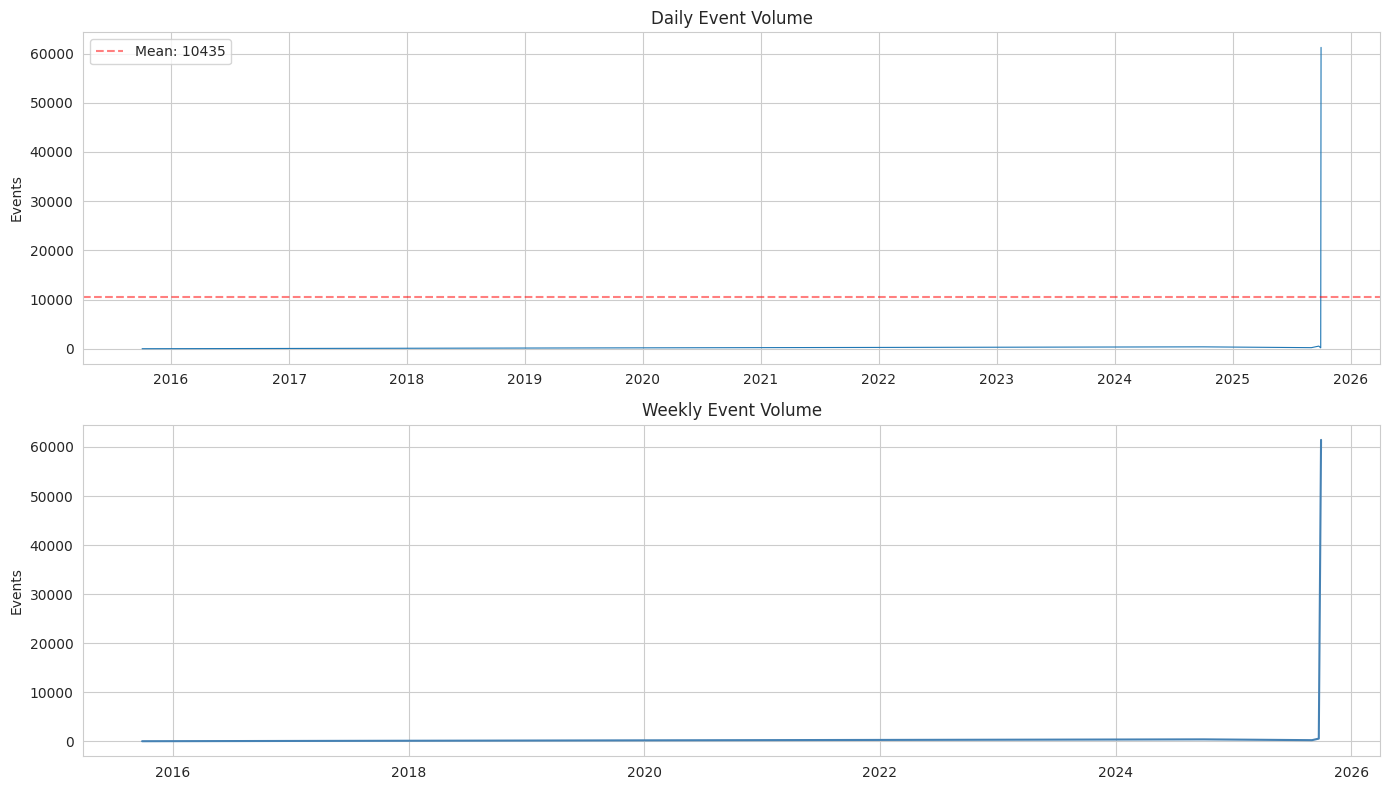

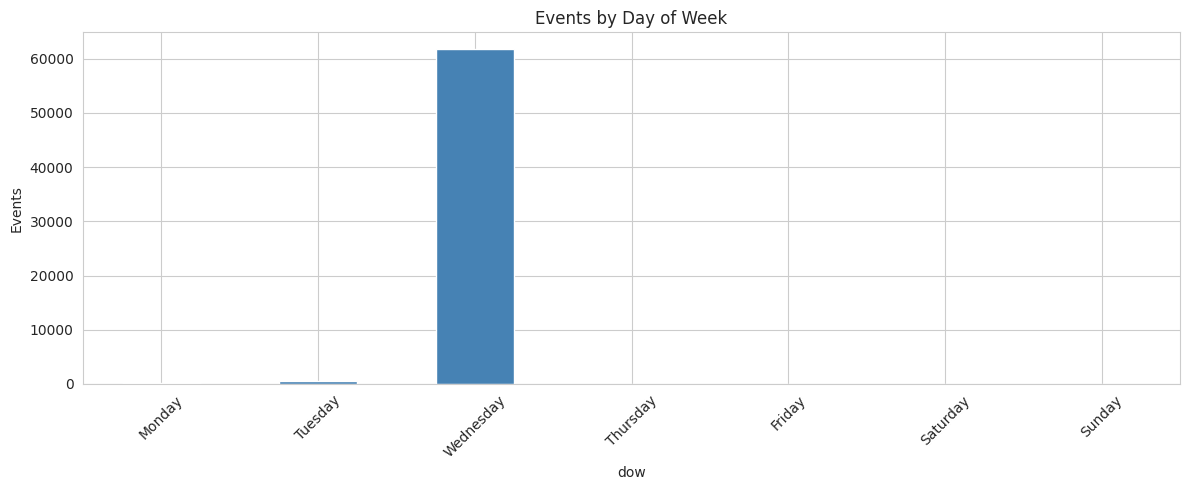

In [15]:
# Daily / weekly volume — aggregate in Spark, plot in pandas
daily = (sdf.groupBy('date').count()
            .orderBy('date')
            .toPandas()
            .set_index('date')['count'])

print(f"Mean events/day:   {daily.mean():.0f}")
print(f"Median events/day: {daily.median():.0f}")
print(f"Max events/day:    {daily.max():,} on {daily.idxmax()}")
print(f"Min events/day:    {daily.min()} on {daily.idxmin()}")

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(daily.index, daily.values, linewidth=0.8)
axes[0].set_title('Daily Event Volume')
axes[0].set_ylabel('Events')
axes[0].axhline(daily.mean(), color='red', linestyle='--', alpha=0.5,
                label=f'Mean: {daily.mean():.0f}')
axes[0].legend()

weekly = (sdf.groupBy('week').count().orderBy('week').toPandas()
             .set_index('week')['count'])
axes[1].plot(weekly.index, weekly.values, linewidth=1.5, color='steelblue')
axes[1].set_title('Weekly Event Volume')
axes[1].set_ylabel('Events')

plt.tight_layout()
plt.show()

# Day-of-week pattern
dow = (sdf.withColumn('dow', F.date_format('date', 'EEEE'))
          .groupBy('dow').count().toPandas()
          .set_index('dow')['count'])
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow.reindex(dow_order).plot(kind='bar', color='steelblue')
plt.title('Events by Day of Week')
plt.ylabel('Events')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Mean events/day:   10435
Median events/day: 308
Max events/day:    61,254 on 2025-10-01
Min events/day:    13 on 2015-10-04


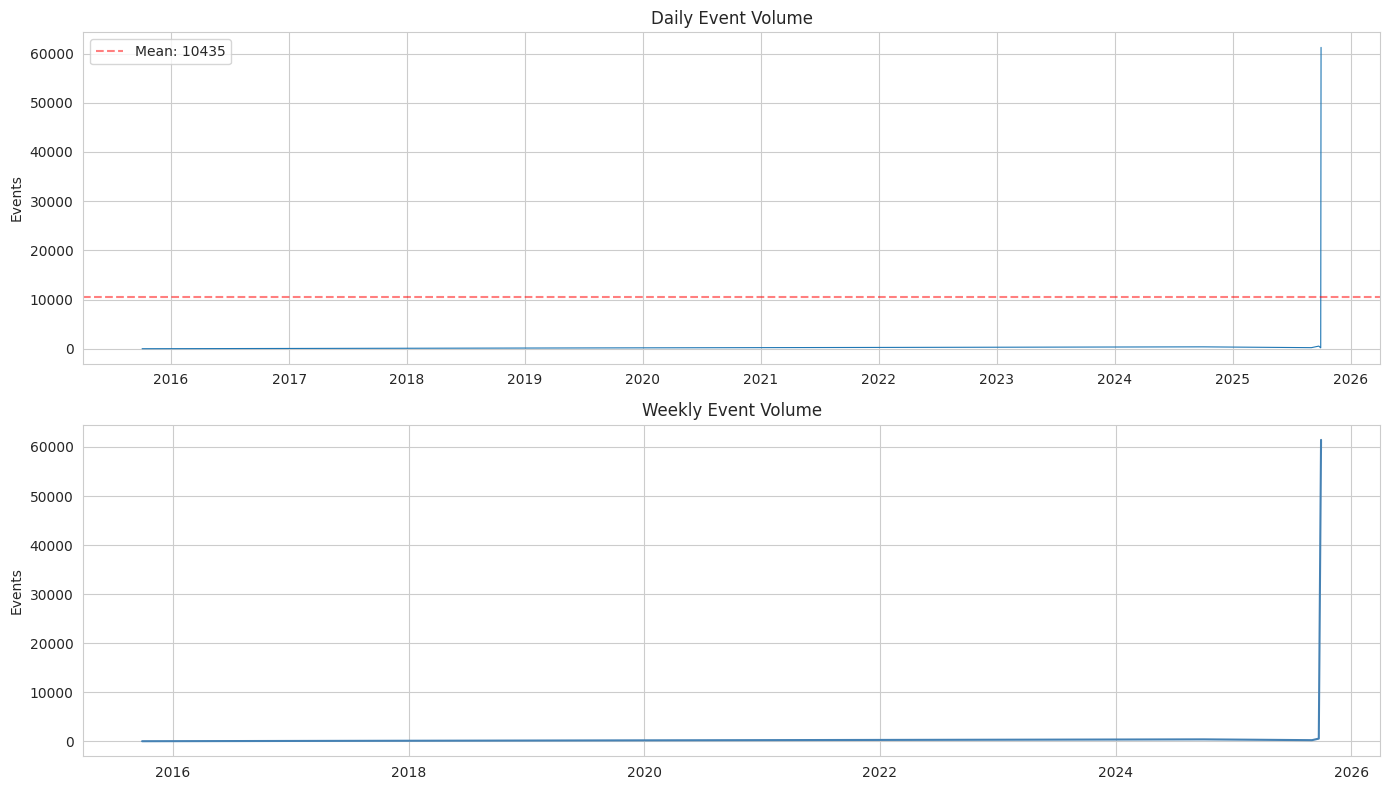

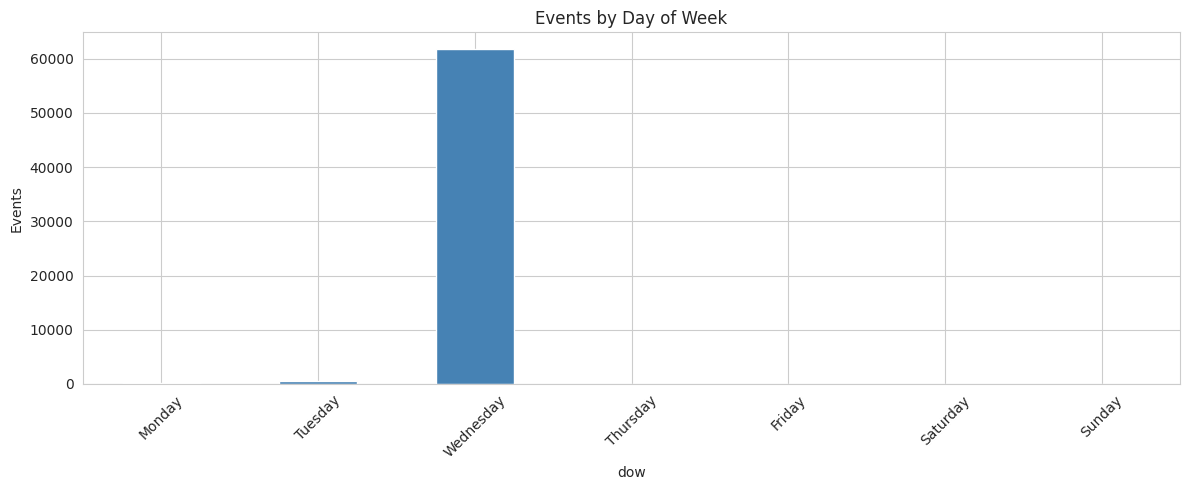

In [16]:
# Daily / weekly volume — aggregate in Spark, plot in pandas
daily = (sdf.groupBy('date').count()
            .orderBy('date')
            .toPandas()
            .set_index('date')['count'])

print(f"Mean events/day:   {daily.mean():.0f}")
print(f"Median events/day: {daily.median():.0f}")
print(f"Max events/day:    {daily.max():,} on {daily.idxmax()}")
print(f"Min events/day:    {daily.min()} on {daily.idxmin()}")

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(daily.index, daily.values, linewidth=0.8)
axes[0].set_title('Daily Event Volume')
axes[0].set_ylabel('Events')
axes[0].axhline(daily.mean(), color='red', linestyle='--', alpha=0.5,
                label=f'Mean: {daily.mean():.0f}')
axes[0].legend()

weekly = (sdf.groupBy('week').count().orderBy('week').toPandas()
             .set_index('week')['count'])
axes[1].plot(weekly.index, weekly.values, linewidth=1.5, color='steelblue')
axes[1].set_title('Weekly Event Volume')
axes[1].set_ylabel('Events')

plt.tight_layout()
plt.show()

# Day-of-week pattern
dow = (sdf.withColumn('dow', F.date_format('date', 'EEEE'))
          .groupBy('dow').count().toPandas()
          .set_index('dow')['count'])
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow.reindex(dow_order).plot(kind='bar', color='steelblue')
plt.title('Events by Day of Week')
plt.ylabel('Events')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Total countries with events: 213
Countries with ≥100 events: 78
Countries with ≥30 events:  127
Countries with <10 events:  42


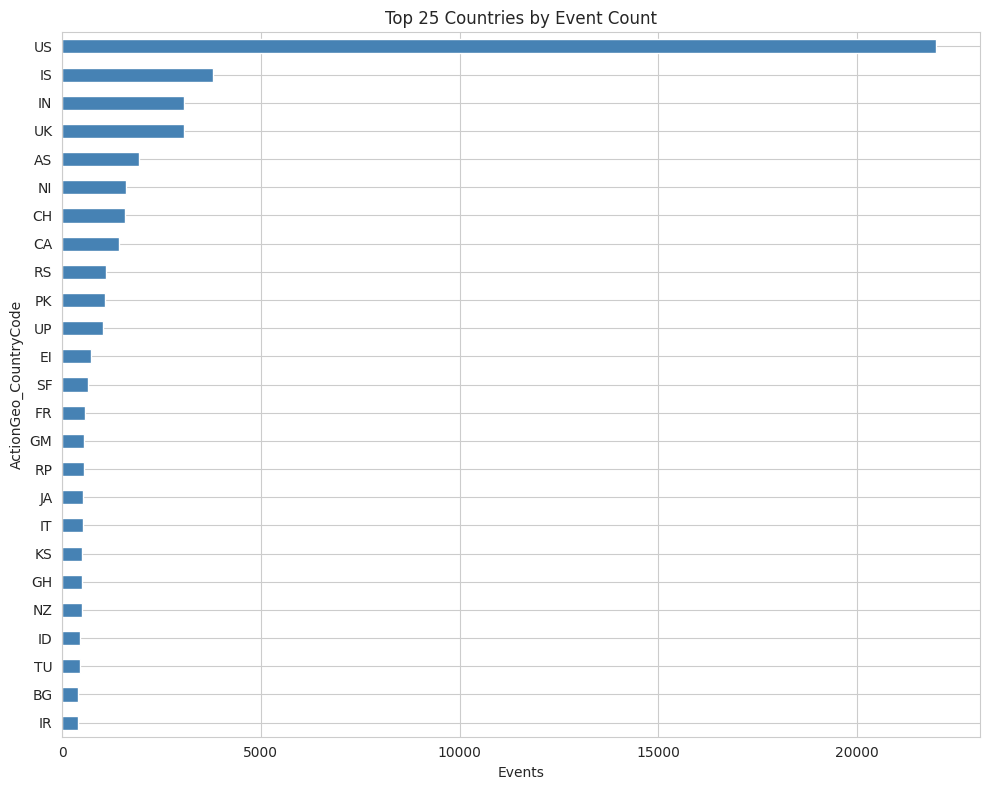


Top 10 countries account for 64.9% of all events


In [17]:
# Country event counts
country_counts = (sdf.groupBy('ActionGeo_CountryCode').count()
                     .toPandas()
                     .set_index('ActionGeo_CountryCode')['count']
                     .sort_values(ascending=False))

print(f"Total countries with events: {len(country_counts)}")
print(f"Countries with ≥100 events: {(country_counts >= 100).sum()}")
print(f"Countries with ≥30 events:  {(country_counts >= 30).sum()}")
print(f"Countries with <10 events:  {(country_counts < 10).sum()}")

fig, ax = plt.subplots(figsize=(10, 8))
country_counts.head(25).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 25 Countries by Event Count')
ax.set_xlabel('Events')
plt.tight_layout()
plt.show()

top10_share = country_counts.head(10).sum() / country_counts.sum() * 100
print(f"\nTop 10 countries account for {top10_share:.1f}% of all events")

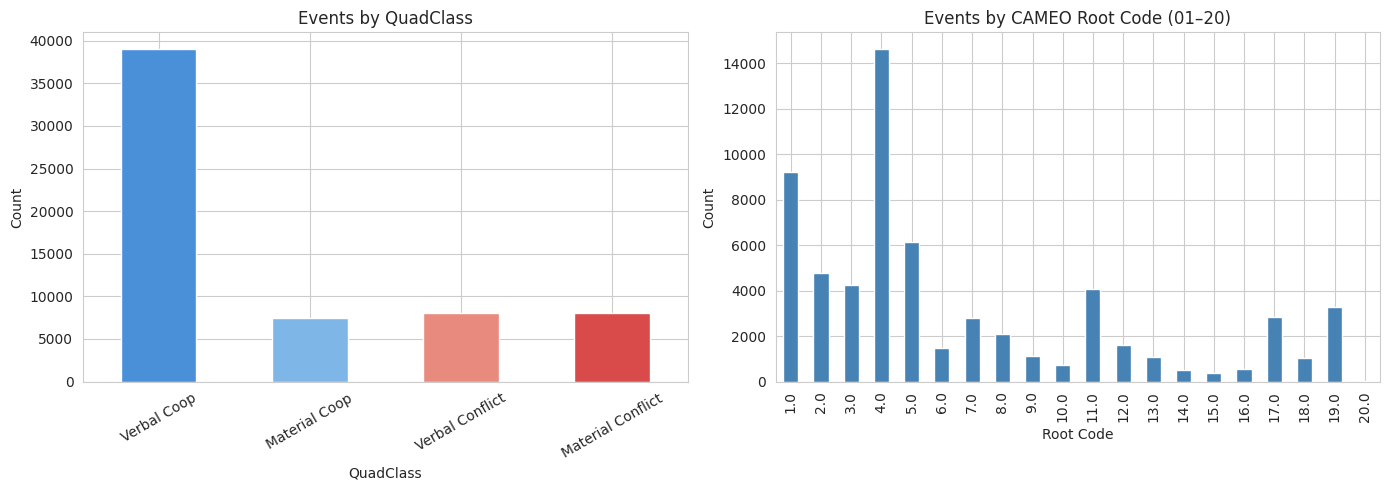

Top 20 countries by material conflict ratio (≥50 events):
         total  material_conflict_ratio  any_conflict_ratio
country                                                    
CG         119                    0.605               0.664
CF         122                    0.451               0.549
MO          77                    0.390               0.584
TS          50                    0.340               0.520
SY         133                    0.301               0.383
NG          51                    0.294               0.294
RW         126                    0.254               0.365
GZ          97                    0.227               0.320
MA         106                    0.226               0.547
WE         116                    0.224               0.336
ZI         167                    0.210               0.371
EC          88                    0.205               0.443
BG         407                    0.204               0.314
MX         316                    0.203   

In [18]:
# QuadClass + EventRootCode distributions
quad_labels = {1: 'Verbal Coop', 2: 'Material Coop', 3: 'Verbal Conflict', 4: 'Material Conflict'}

quad_counts = (sdf.groupBy('QuadClass').count().orderBy('QuadClass')
                  .toPandas().dropna().set_index('QuadClass')['count'])
root_counts = (sdf.groupBy('EventRootCode').count().orderBy('EventRootCode')
                  .toPandas().dropna().set_index('EventRootCode')['count'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
quad_counts.rename(index=quad_labels).plot(
    kind='bar', ax=axes[0], color=['#4a90d9', '#7eb6e8', '#e88b7e', '#d94a4a']
)
axes[0].set_title('Events by QuadClass')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

root_counts.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Events by CAMEO Root Code (01–20)')
axes[1].set_xlabel('Root Code')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Conflict ratio per country — Spark pivot
country_quad = (sdf.groupBy('ActionGeo_CountryCode')
                   .pivot('QuadClass', [1, 2, 3, 4])
                   .count()
                   .fillna(0)
                   .toPandas()
                   .rename(columns={'ActionGeo_CountryCode': 'country',
                                    '1': 1, '2': 2, '3': 3, '4': 4})
                   .set_index('country'))
country_quad.columns = [int(c) if str(c).isdigit() else c for c in country_quad.columns]
country_quad['total'] = country_quad[[1, 2, 3, 4]].sum(axis=1)
country_quad['material_conflict_ratio'] = country_quad[4] / country_quad['total']
country_quad['any_conflict_ratio']      = (country_quad[3] + country_quad[4]) / country_quad['total']

top_unstable = (country_quad[country_quad['total'] >= 50]
                .sort_values('material_conflict_ratio', ascending=False)
                .head(20))

print("Top 20 countries by material conflict ratio (≥50 events):")
print(top_unstable[['total', 'material_conflict_ratio', 'any_conflict_ratio']].round(3))

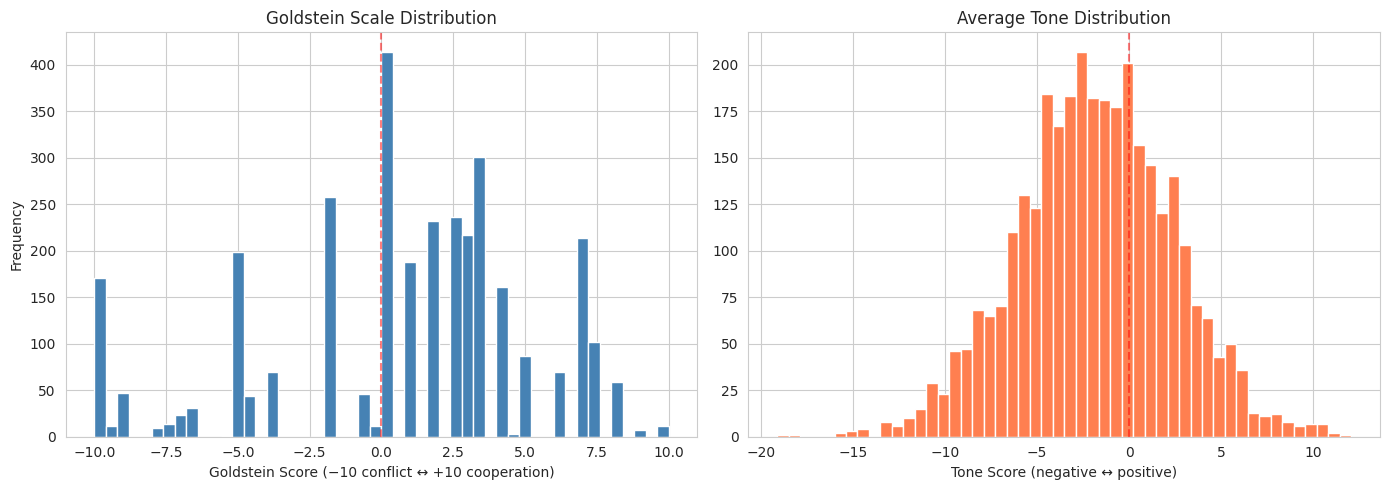

Goldstein–AvgTone correlation (sample): 0.341


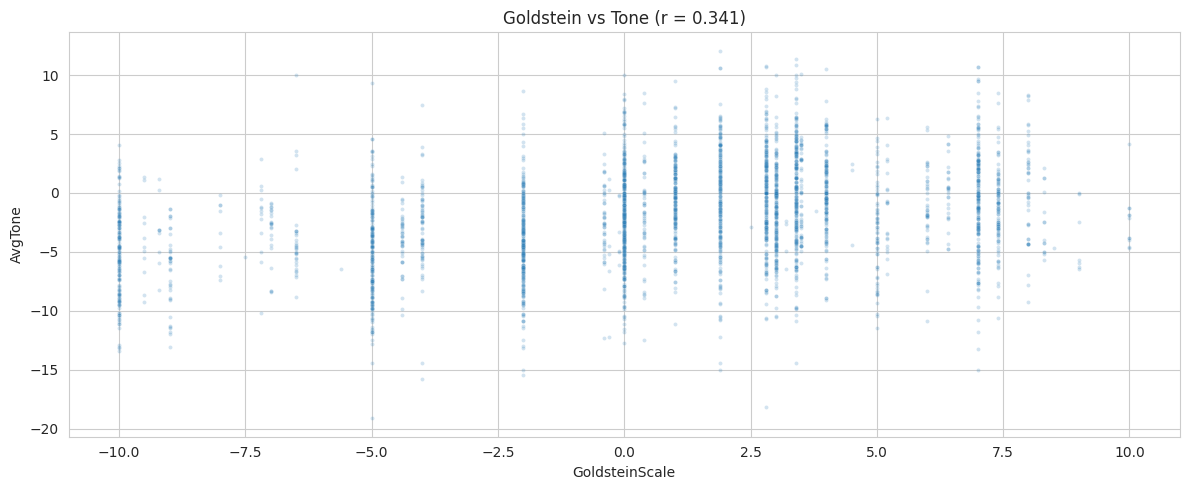

In [19]:
# Goldstein + AvgTone distributions — sample from Spark for plotting
sample_pdf = (sdf.select('GoldsteinScale', 'AvgTone')
                 .dropna()
                 .sample(fraction=0.05, seed=42)  # adjust fraction to taste
                 .toPandas())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sample_pdf['GoldsteinScale'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.5)
axes[0].set_title('Goldstein Scale Distribution')
axes[0].set_xlabel('Goldstein Score (−10 conflict ↔ +10 cooperation)')
axes[0].set_ylabel('Frequency')

sample_pdf['AvgTone'].hist(bins=50, ax=axes[1], color='coral', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Average Tone Distribution')
axes[1].set_xlabel('Tone Score (negative ↔ positive)')

plt.tight_layout()
plt.show()

# Correlation already computed in Spark above; redo on sample for scatter
corr = sample_pdf.corr().iloc[0, 1]
print(f"Goldstein–AvgTone correlation (sample): {corr:.3f}")

sns.scatterplot(data=sample_pdf.sample(min(10000, len(sample_pdf)), random_state=42),
                x='GoldsteinScale', y='AvgTone', alpha=0.2, s=8)
plt.title(f'Goldstein vs Tone (r = {corr:.3f})')
plt.tight_layout()
plt.show()

Top 15 most conflict-prone countries (by mean Goldstein):
                       n_events  goldstein_mean  goldstein_std  tone_mean  \
ActionGeo_CountryCode                                                       
CG                          119           -4.10           5.23      -8.29   
MO                           77           -3.02           5.47      -4.65   
MA                          106           -2.37           5.16      -7.93   
CF                          122           -1.89           5.04      -9.05   
TS                           50           -1.33           5.37      -5.03   
SY                          133           -1.19           5.80      -2.75   
EC                           88           -1.00           5.56      -5.15   
HU                           76           -0.82           4.64      -1.74   
WE                          116           -0.73           5.23      -4.44   
NG                           51           -0.66           5.51      -6.23   
ZI                

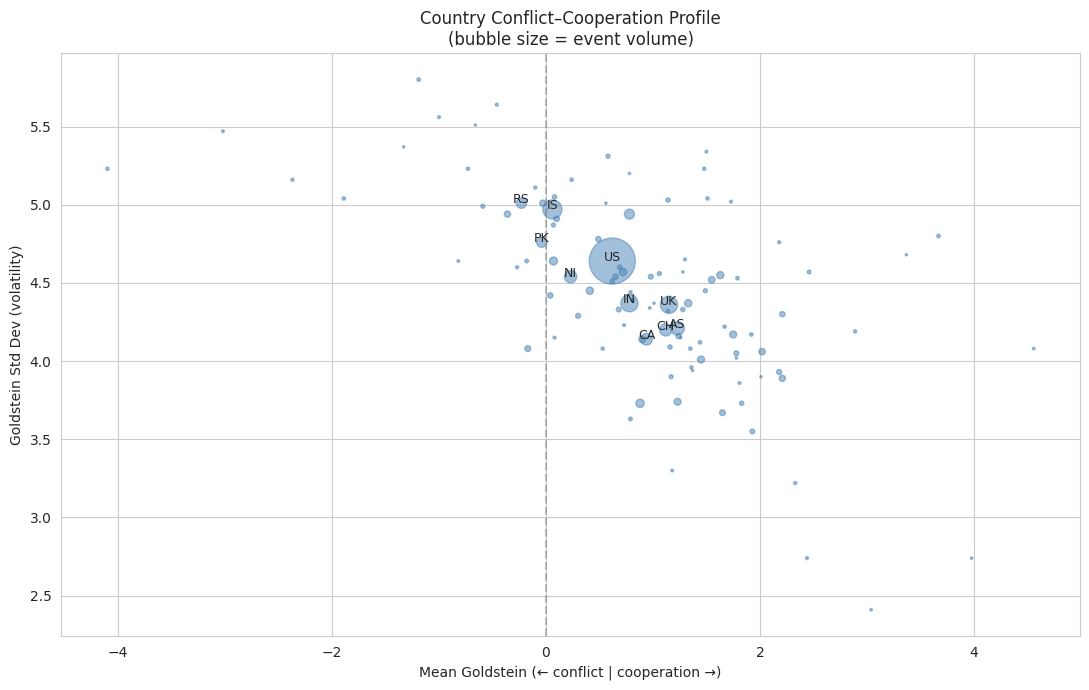

In [20]:
# Country-level intensity — full aggregation in Spark, then to pandas for ranking
country_intensity = (sdf.groupBy('ActionGeo_CountryCode')
    .agg(
        F.count('GLOBALEVENTID').alias('n_events'),
        F.mean('GoldsteinScale').alias('goldstein_mean'),
        F.stddev('GoldsteinScale').alias('goldstein_std'),
        F.mean('AvgTone').alias('tone_mean'),
        F.stddev('AvgTone').alias('tone_std'),
        F.mean('NumMentions').alias('mentions_mean'),
    )
    .filter(F.col('n_events') >= 50)
    .toPandas()
    .set_index('ActionGeo_CountryCode')
    .round(2))

print("Top 15 most conflict-prone countries (by mean Goldstein):")
print(country_intensity.nsmallest(15, 'goldstein_mean'))

print("\nTop 15 most cooperative countries (by mean Goldstein):")
print(country_intensity.nlargest(15, 'goldstein_mean'))

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(country_intensity['goldstein_mean'], country_intensity['goldstein_std'],
           s=country_intensity['n_events'] / 20, alpha=0.5, color='steelblue')

notable = country_intensity.nlargest(10, 'n_events').index
for country in notable:
    row = country_intensity.loc[country]
    ax.annotate(country, (row['goldstein_mean'], row['goldstein_std']),
                fontsize=9, ha='center')

ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Mean Goldstein (← conflict | cooperation →)')
ax.set_ylabel('Goldstein Std Dev (volatility)')
ax.set_title('Country Conflict–Cooperation Profile\n(bubble size = event volume)')
plt.tight_layout()
plt.show()

In [21]:
# Actor activity and bilateral pairs
print("Top 20 most active Actor1 countries:")
(sdf.groupBy('Actor1CountryCode').count()
    .orderBy(F.desc('count'))
    .limit(20)
    .show(truncate=False))

print("\nTop 20 bilateral interaction pairs:")
(sdf.filter(F.col('Actor1CountryCode').isNotNull() &
            F.col('Actor2CountryCode').isNotNull() &
            (F.col('Actor1CountryCode') != F.col('Actor2CountryCode')))
    .groupBy('Actor1CountryCode', 'Actor2CountryCode')
    .count()
    .orderBy(F.desc('count'))
    .limit(20)
    .show(truncate=False))

Top 20 most active Actor1 countries:
+-----------------+-----+
|Actor1CountryCode|count|
+-----------------+-----+
|NULL             |27516|
|USA              |11274|
|ISR              |1700 |
|GBR              |1656 |
|AUS              |1046 |
|CHN              |1000 |
|PSE              |920  |
|RUS              |773  |
|CAN              |687  |
|NGA              |642  |
|IND              |618  |
|PAK              |585  |
|UKR              |585  |
|EUR              |527  |
|FRA              |471  |
|AFR              |422  |
|DEU              |402  |
|IRL              |396  |
|ITA              |372  |
|JPN              |363  |
+-----------------+-----+


Top 20 bilateral interaction pairs:
+-----------------+-----------------+-----+
|Actor1CountryCode|Actor2CountryCode|count|
+-----------------+-----------------+-----+
|ISR              |PSE              |367  |
|PSE              |ISR              |283  |
|USA              |ISR              |211  |
|UKR              |RUS              |

In [22]:
# Save EDA tables
country_intensity.to_csv(f'{PROCESSED_DIR}/eda_country_intensity.csv')
country_quad.to_csv(f'{PROCESSED_DIR}/eda_country_quad.csv')
print(f"Saved EDA outputs to {PROCESSED_DIR}/")

Saved EDA outputs to /content/drive/MyDrive/gdelt_data/processed/


feature engineering

In [23]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Re-read cleaned data with Spark
CLEAN_PATH = '/content/drive/MyDrive/gdelt_data/cleaned/events_cleaned.parquet'
sdf = spark.read.parquet(CLEAN_PATH)
print(f"Loaded {sdf.count():,} events")

Loaded 62,611 events


In [24]:
TIME_BUCKET = 'month'        # 'month' or 'week'
MIN_EVENTS_PER_BUCKET = 5

# ---- Core aggregates ----
agg = (sdf
    .withColumnRenamed('ActionGeo_CountryCode', 'country')
    .withColumnRenamed(TIME_BUCKET, 'period')
    .groupBy('country', 'period')
    .agg(
        F.count('GLOBALEVENTID').alias('n_events'),
        F.mean('GoldsteinScale').alias('goldstein_mean'),
        F.stddev('GoldsteinScale').alias('goldstein_std'),
        F.min('GoldsteinScale').alias('goldstein_min'),
        F.mean('AvgTone').alias('tone_mean'),
        F.stddev('AvgTone').alias('tone_std'),
        F.sum('NumMentions').alias('mentions_sum'),
        F.mean('NumMentions').alias('mentions_mean'),
        F.mean('NumSources').alias('sources_mean'),
        F.countDistinct('Actor1CountryCode').alias('n_unique_actor1'),
        F.countDistinct('Actor2CountryCode').alias('n_unique_actor2'),
    ))

# ---- QuadClass pivot ----
quad = (sdf
    .withColumnRenamed('ActionGeo_CountryCode', 'country')
    .withColumnRenamed(TIME_BUCKET, 'period')
    .groupBy('country', 'period')
    .pivot('QuadClass', [1, 2, 3, 4])
    .count()
    .fillna(0))

for q in [1, 2, 3, 4]:
    quad = quad.withColumnRenamed(str(q), f'quad_{q}_count')

# ---- Merge + derived ratios (all in Spark) ----
panel_sdf = (agg.join(quad, ['country', 'period'], 'left')
    .fillna(0, subset=[f'quad_{q}_count' for q in [1, 2, 3, 4]])
    .withColumn('verbal_coop_ratio',       F.col('quad_1_count') / F.col('n_events'))
    .withColumn('material_coop_ratio',     F.col('quad_2_count') / F.col('n_events'))
    .withColumn('verbal_conflict_ratio',   F.col('quad_3_count') / F.col('n_events'))
    .withColumn('material_conflict_ratio', F.col('quad_4_count') / F.col('n_events'))
    .withColumn('any_conflict_ratio',
                (F.col('quad_3_count') + F.col('quad_4_count')) / F.col('n_events'))
    .filter(F.col('n_events') >= MIN_EVENTS_PER_BUCKET)
    .fillna(0, subset=['goldstein_std', 'tone_std']))

# Persist as parquet, then bring into pandas (the panel is small — countries × months)
panel_path = f'{PROCESSED_DIR}/panel_country_{TIME_BUCKET}.parquet'
panel_sdf.write.mode('overwrite').parquet(panel_path)

panel = pd.read_parquet(panel_path)
print(f"Panel rows: {len(panel):,}")
print(f"Unique countries: {panel['country'].nunique()}")
print(f"Unique periods:   {panel['period'].nunique()}")
print(f"\nSaved panel to {panel_path}")
panel.head()

Panel rows: 245
Unique countries: 190
Unique periods:   3

Saved panel to /content/drive/MyDrive/gdelt_data/processed/panel_country_month.parquet


,country,period,n_events,goldstein_mean,goldstein_std,goldstein_min,tone_mean,tone_std,mentions_sum,mentions_mean,...,n_unique_actor2,quad_1_count,quad_2_count,quad_3_count,quad_4_count,verbal_coop_ratio,material_coop_ratio,verbal_conflict_ratio,material_conflict_ratio,any_conflict_ratio
0,IN,2024-10-01,10,-1.230000,6.150167,-9.0,-0.361426,4.144595,66.0,6.600000,...,2,2,3,4,1,0.200000,0.300000,0.400000,0.100000,0.500000
1,NL,2025-09-01,8,1.350000,7.588713,-10.0,-6.737196,2.926961,52.0,6.500000,...,1,5,0,2,1,0.625000,0.000000,0.250000,0.125000,0.375000
2,US,2025-09-01,356,1.253652,4.202208,-10.0,-2.357545,3.716784,1337.0,3.755618,...,23,249,32,37,38,0.699438,0.089888,0.103933,0.106742,0.210674
3,MO,2025-10-01,76,-3.102632,5.454441,-10.0,-4.719594,5.163064,464.0,6.105263,...,7,28,3,15,30,0.368421,0.039474,0.197368,0.394737,0.592105
4,CS,2025-10-01,13,-0.292308,3.744654,-10.0,0.048721,4.175774,82.0,6.307692,...,2,10,0,1,2,0.769231,0.000000,0.076923,0.153846,0.230769


In [25]:
# Feature matrix for clustering (pandas + sklearn — panel is small enough)
FEATURE_COLS = [
    'n_events',
    'goldstein_mean',
    'goldstein_std',
    'goldstein_min',
    'tone_mean',
    'tone_std',
    'mentions_mean',
    'n_unique_actor1',
    'verbal_coop_ratio',
    'material_coop_ratio',
    'verbal_conflict_ratio',
    'material_conflict_ratio',
]

X_raw = panel[FEATURE_COLS].copy()

# Log-transform skewed count features
for col in ['n_events', 'mentions_mean', 'n_unique_actor1']:
    X_raw[col] = np.log1p(X_raw[col])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Feature matrix shape: {X_scaled.shape}")
print(f"Features: {FEATURE_COLS}")

pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"After PCA: {X_pca.shape} (explained variance: {pca.explained_variance_ratio_.sum():.3f})")

Feature matrix shape: (245, 12)
Features: ['n_events', 'goldstein_mean', 'goldstein_std', 'goldstein_min', 'tone_mean', 'tone_std', 'mentions_mean', 'n_unique_actor1', 'verbal_coop_ratio', 'material_coop_ratio', 'verbal_conflict_ratio', 'material_conflict_ratio']
After PCA: (245, 8) (explained variance: 0.972)


Clustering